# Session 9, Notebook 3: A Borrowing Constraint and Discrete Income, Finite Differences against a PINN

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 2, 15:10-16:00, Physics-informed neural networks: applications and hands-on
**Slides:** `09_PINNs_Applications.pdf`
**Notebook role:** self-study
**Author:** Simon Scheidegger (HEC, University of Lausanne)

One step past cake-eating: a household with a borrowing constraint and a two-state Markov income,
in partial equilibrium (prices given). There is no closed form, so the reference is the standard
upwind finite-difference (FD) scheme of Achdou, Han, Lasry, Lions and Moll (2022). The same
coupled HJB system is then handed to a PINN with the same economics, and the two are compared.

The point of the notebook is the comparison, and it does not flatter the PINN. The FD scheme
converges in 13 iterations; the PINN reaches a small residual but a consumption policy that is
far from the reference, and nothing in the PINN's own output says so. How to tell, and why it
happens, is the lesson.

| Section | Content |
|:--|:--|
| 1 | The model and its HJB system |
| 2 | The finite-difference reference |
| 3 | The PINN: value network, first-order condition, state constraint |
| 4 | Comparison, and how to read it |

In [1]:
SEED = 42

In [2]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(SEED); np.random.seed(SEED)
torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                     "legend.fontsize": 9, "font.family": "serif", "mathtext.fontset": "cm",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
C_TRUE, C_SOFT, C_HARD = "#264653", "#e76f51", "#2a9d8f"

FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = True   # the stored run writes the figures the slides use
def savefig(fig, name):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

## 1. The model

$$\max_{c}\ \mathbb{E}_0 \int_0^\infty e^{-\rho t}\,\frac{c^{1-\gamma}}{1-\gamma}\,dt,
  \qquad \dot a = r a + w z - c, \qquad a \ge \underline a,$$

with $z \in \{z_L, z_H\}$ switching at Poisson rates $\lambda_{12}, \lambda_{21}$. In state $j$,

$$\rho V_j(a) = \max_c\Bigl\{u(c) + V_j'(a)\,(ra + wz_j - c)\Bigr\} + \lambda_{jk}\bigl(V_k(a) - V_j(a)\bigr),
  \qquad c_j = V_j'(a)^{-1/\gamma}.$$

Two coupled first-order equations. The borrowing constraint is a **state constraint**: at
$a = \underline a$ the household may not dissave, $s_j(\underline a) = ra + wz_j - c_j \ge 0$,
equivalently $V_j'(\underline a) \ge u'(r\underline a + wz_j)$. It binds in the low-income state
and is slack in the high-income state. At the upper end of the computational domain nothing is
imposed: the household dissaves there, so the flow points inward.

| $\rho$ | $\gamma$ | $r$ | $w$ | $z_L, z_H$ | $\lambda_{12} = \lambda_{21}$ | $\underline a, \bar a$ |
|:--:|:--:|:--:|:--:|:--:|:--:|:--:|
| 0.02 | 2 | 0.01 | 1 | 0.8, 1.2 | 1/3 | $-1$, 20 |

In [3]:
rho, gamma, r, w = 0.02, 2.0, 0.01, 1.0
z = np.array([0.8, 1.2]); lam = np.array([1.0 / 3.0, 1.0 / 3.0])   # lam[0] = lambda_12, lam[1] = lambda_21
a_min, a_max = -1.0, 20.0

u = lambda c: c**(1.0 - gamma) / (1.0 - gamma)
u_prime = lambda c: c**(-gamma)
u_prime_inv = lambda x: x**(-1.0 / gamma)

## 2. The finite-difference reference

The upwind implicit scheme: forward and backward differences of $V$, consumption from the
first-order condition for each, the difference chosen by the sign of the savings it implies
(forward if saving, backward if dissaving, neither if the household stays put), and an implicit
step $\bigl(\tfrac{1}{\Delta} + \rho\bigr)V^{n+1} - A V^{n+1} = u(c) + V^n/\Delta$ with a large
$\Delta$. The state constraint enters as the backward difference at $\underline a$, set to
$u'(r\underline a + wz_j)$.

In [4]:
J = 500
a_grid = np.linspace(a_min, a_max, J); da = a_grid[1] - a_grid[0]; n = 2 * J
income = r * a_grid[None, :] + w * z[:, None]          # [2, J]
A_switch = sp.kron(np.array([[-lam[0], lam[0]], [lam[1], -lam[1]]]), sp.eye(J), format="csr")

def fd_policies(V):
    VaF = np.zeros((2, J)); VaB = np.zeros((2, J))
    VaF[:, :-1] = np.maximum((V[:, 1:] - V[:, :-1]) / da, 1e-8)
    VaB[:, 1:]  = np.maximum((V[:, 1:] - V[:, :-1]) / da, 1e-8)
    VaF[:, -1] = u_prime(income[:, -1])                  # no saving out of the top of the grid
    VaB[:, 0]  = u_prime(income[:, 0])                   # the state constraint at a_min
    cF, cB = u_prime_inv(VaF), u_prime_inv(VaB)
    sF, sB = income - cF, income - cB
    IF = (sF > 0).astype(float); IB = ((sB < 0) & (sF <= 0)).astype(float); I0 = 1.0 - IF - IB
    c = cF * IF + cB * IB + income * I0
    s = sF * IF + sB * IB
    return c, s, sF * IF, sB * IB

Delta, tol = 1000.0, 1e-8
V = u(income) / rho                                      # initial guess: consume income forever
t0 = time.time()
for it in range(1, 501):
    c_fd, s_fd, sF_up, sB_up = fd_policies(V)
    diag0 = (-sF_up / da + sB_up / da).reshape(n); upper = (sF_up / da).reshape(n); lower = (-sB_up / da).reshape(n)
    A = (sp.diags(diag0, 0, shape=(n, n)) + sp.diags(upper[:-1], 1, shape=(n, n)) + sp.diags(lower[1:], -1, shape=(n, n))).tocsr() + A_switch
    B = (1.0 / Delta + rho) * sp.eye(n, format="csr") - A
    V_new = spsolve(B, u(c_fd).reshape(n) + V.reshape(n) / Delta).reshape(2, J)
    gap = np.abs(V_new - V).max(); V = V_new
    if gap < tol:
        break
V_fd = V.copy(); c_fd, s_fd, _, _ = fd_policies(V_fd)
print(f"FD: {it} iterations, final change {gap:.1e}, {time.time() - t0:.2f} s on {J} points")
print(f"at a_min: c = {c_fd[:, 0].round(4)}, savings s = {s_fd[:, 0].round(4)}   (state 1 constrained, state 2 saves)")
print(f"at a_max: c = {c_fd[:, -1].round(4)}, savings s = {s_fd[:, -1].round(4)}   (both dissave: the flow points inward)")

FD: 13 iterations, final change 3.8e-09, 0.03 s on 500 points
at a_min: c = [0.79   0.9563], savings s = [0.     0.2337]   (state 1 constrained, state 2 saves)
at a_max: c = [1.5901 1.6019], savings s = [-0.5901 -0.2019]   (both dissave: the flow points inward)


## 3. The PINN

A network with one input and two outputs, $(V_1, V_2)$, scaled so that the outputs are of order
one. Consumption comes from the first-order condition, as in `09_01`, with the `softplus` safeguard.
The loss is the residual of both equations at 1,000 resampled wealth levels plus the state
constraint at $\underline a$ as an inequality penalty, $\max(0, -s_j(\underline a))^2$, for both
states. Nothing is imposed at $\bar a$. Adam for 5,000 steps, then L-BFGS on 1,000 fixed points.

In [5]:
class ValueNet(nn.Module):
    """a -> (V_1, V_2); the output scale matches the FD values, which lie between -52 and -35."""
    def __init__(self, width=64, depth=3):
        super().__init__()
        layers, d_in = [], 1
        for _ in range(depth):
            layers += [nn.Linear(d_in, width), nn.Tanh()]; d_in = width
        layers += [nn.Linear(width, 2)]
        self.net = nn.Sequential(*layers)
    def forward(self, a):
        return -45.0 + 10.0 * self.net(2.0 * (a - a_min) / (a_max - a_min) - 1.0)

z_t, lam_t = torch.tensor(z), torch.tensor(lam)

def policies_and_residual(net, a):
    """Returns V [N,2], c [N,2], s [N,2], R [N,2] at the wealth levels a [N,1]."""
    a = a.clone().requires_grad_(True)
    V = net(a)
    V_a = torch.cat([torch.autograd.grad(V[:, j].sum(), a, create_graph=True)[0] for j in range(2)], dim=1)
    V_a = nn.functional.softplus(V_a) + 1e-8
    c = V_a ** (-1.0 / gamma)
    s = r * a + w * z_t - c
    switch = torch.stack([lam_t[0] * (V[:, 1] - V[:, 0]), lam_t[1] * (V[:, 0] - V[:, 1])], dim=1)
    R = rho * V - u(c) - V_a * s - switch
    return V, c, s, R

a_lo = torch.full((1, 1), a_min)
def pinn_loss(net, a):
    _, _, _, R = policies_and_residual(net, a)
    _, _, s_lo, _ = policies_and_residual(net, a_lo)
    return torch.mean(R ** 2) + 10.0 * torch.sum(torch.relu(-s_lo) ** 2)

torch.manual_seed(SEED); net = ValueNet()
n_adam, n_lbfgs = 5000, 300
opt = torch.optim.Adam(net.parameters(), lr=1e-3); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, n_adam)
t0 = time.time()
for step in range(1, n_adam + 1):
    loss = pinn_loss(net, a_min + (a_max - a_min) * torch.rand(1000, 1))
    opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(net.parameters(), 20.0); opt.step(); sched.step()
    if step % 1000 == 0 or step == 1:
        print(f"Adam {step:5d}  loss {loss.item():.3e}")
print(f"Adam stage: {time.time() - t0:.0f} s")
a_fixed = torch.linspace(a_min, a_max, 1000).reshape(-1, 1)
lbfgs = torch.optim.LBFGS(net.parameters(), max_iter=n_lbfgs, history_size=50, tolerance_grad=1e-12, tolerance_change=1e-14, line_search_fn="strong_wolfe")
n_eval = [0]
def closure():
    lbfgs.zero_grad(); l = pinn_loss(net, a_fixed); l.backward(); n_eval[0] += 1; return l
t0 = time.time(); lbfgs.step(closure)
print(f"L-BFGS stage: {n_eval[0]} evaluations, {time.time() - t0:.0f} s, final loss {pinn_loss(net, a_fixed).item():.3e}")

Adam     1  loss 2.088e+00


Adam  1000  loss 6.524e-04


Adam  2000  loss 2.937e-04


Adam  3000  loss 1.817e-04


Adam  4000  loss 1.198e-04


Adam  5000  loss 1.160e-04
Adam stage: 49 s


L-BFGS stage: 368 evaluations, 4 s, final loss 4.363e-06


## 4. Comparison, and how to read it

The PINN is evaluated on the FD grid. Three things to look at: the value functions, the
consumption policies, and the PINN's own residual.

             rel. L2 error, state 1    state 2     max |error|, state 1    state 2
value V                     3.4e-02    2.9e-02                     2.07       1.79
cons. c                     2.6e-01    2.6e-01                     0.53       0.54
PINN residual on the grid: RMS 2.1e-03, max 2.5e-02   (compare rho V ~ 0.9)
at a_min: PINN c = [0.79   0.8687], s = [-0.      0.3213];   FD c = [0.79   0.9563], s = [0.     0.2337]
at a_max: PINN c = [1.0598 1.0624], s = [-0.0598  0.3376];   FD c = [1.5901 1.6019], s = [-0.5901 -0.2019]


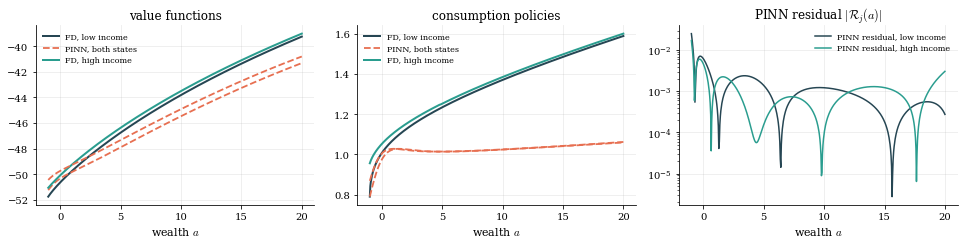

In [6]:
a_t = torch.tensor(a_grid).reshape(-1, 1)
V_p, c_p, s_p, R_p = policies_and_residual(net, a_t)
V_p, c_p, s_p, R_p = (x.detach().numpy().T for x in (V_p, c_p, s_p, R_p))   # [2, J]
rel_l2 = lambda x, ref: np.sqrt(np.mean((x - ref) ** 2)) / np.sqrt(np.mean(ref ** 2))

print(f"{'':10s} {'rel. L2 error, state 1':>24s} {'state 2':>10s}   {'max |error|, state 1':>22s} {'state 2':>10s}")
print(f"{'value V':10s} {rel_l2(V_p[0], V_fd[0]):24.1e} {rel_l2(V_p[1], V_fd[1]):10.1e}   {np.abs(V_p[0] - V_fd[0]).max():22.2f} {np.abs(V_p[1] - V_fd[1]).max():10.2f}")
print(f"{'cons. c':10s} {rel_l2(c_p[0], c_fd[0]):24.1e} {rel_l2(c_p[1], c_fd[1]):10.1e}   {np.abs(c_p[0] - c_fd[0]).max():22.2f} {np.abs(c_p[1] - c_fd[1]).max():10.2f}")
print(f"PINN residual on the grid: RMS {np.sqrt(np.mean(R_p ** 2)):.1e}, max {np.abs(R_p).max():.1e}   (compare rho V ~ {abs(rho * V_fd).mean():.1f})")
print(f"at a_min: PINN c = {c_p[:, 0].round(4)}, s = {s_p[:, 0].round(4)};   FD c = {c_fd[:, 0].round(4)}, s = {s_fd[:, 0].round(4)}")
print(f"at a_max: PINN c = {c_p[:, -1].round(4)}, s = {s_p[:, -1].round(4)};   FD c = {c_fd[:, -1].round(4)}, s = {s_fd[:, -1].round(4)}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5))
for j, (col, lab) in enumerate([(C_TRUE, "low income"), (C_HARD, "high income")]):
    axes[0].plot(a_grid, V_fd[j], color=col, lw=2, label=f"FD, {lab}"); axes[0].plot(a_grid, V_p[j], "--", color=C_SOFT, lw=1.8, label="PINN, both states" if j == 0 else None)
    axes[1].plot(a_grid, c_fd[j], color=col, lw=2, label=f"FD, {lab}"); axes[1].plot(a_grid, c_p[j], "--", color=C_SOFT, lw=1.8, label="PINN, both states" if j == 0 else None)
    axes[2].semilogy(a_grid, np.abs(R_p[j]), color=col, lw=1.5, label=f"PINN residual, {lab}")
axes[0].set_title("value functions"); axes[1].set_title("consumption policies"); axes[2].set_title("PINN residual $|\\mathcal{R}_j(a)|$")
for ax in axes:
    ax.set_xlabel("wealth $a$"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); savefig(fig, "pinn_pe_hjb"); plt.show()

## What happened, how to tell, and what to use

**What happened.** The finite-difference scheme converges in 13 iterations. The PINN reaches a
loss of $4\times10^{-6}$, a residual of $2\times10^{-3}$ RMS against $\rho V \approx 0.9$, and value
functions within 3 % of the reference. Its consumption policy is 26 % off: the PINN household
consumes roughly its income at every wealth level, $c$ between 0.8 and 1.06, where the reference
household with 20 units of wealth and $\rho > r$ dissaves 0.6 per year. The PINN value function is
nearly a straight line; its slope, $V' \approx 0.9$, is what produces the flat policy.

**How to tell.** Not from the residual: $10^{-3}$ looks like success, and the loss kept falling
throughout. From a benchmark, which is why this notebook has one. And from the economics: an
impatient household with a large stock of wealth must run it down, and a policy that says otherwise
is wrong before any error is computed. Read the policy, not the loss.

**Why.** The equation is first order and its derivative enters multiplied by the savings
$s_j(a)$. Where a candidate policy has small savings the derivative term nearly drops out, and the
remaining equation, $\rho V_j = u(c_j) + \lambda_{jk}(V_k - V_j)$, is nearly satisfied by many smooth
value functions. The residual loss is close to blind to the difference between the optimal
policy and a policy that stays put. The upwind scheme is not: it propagates values along the
direction of the flow, which is exactly what selects the constrained viscosity solution of a
first-order HJB (Achdou et al. 2022). Variants tried while preparing this notebook, the inequality
at both ends of the grid, an equality for the binding state, a separate consumption head with the
first-order condition as a penalty, a viscosity term $\varepsilon V''$, and a warm start from the
finite-difference values, all end at the same flat policy.

**What to use.** For a first-order HJB with a state constraint in one or two dimensions, the grid:
it is faster, more accurate, and its error shrinks with the grid. PINNs pay off where the grid is
the problem, in several continuous dimensions, and on second-order equations, where a diffusion term
keeps the derivatives in the equation at every point.

### Exercises

1. Double `n_adam`. Does the residual fall? Does the policy move?
2. Add the finite-difference consumption at five wealth levels as a data term, as in the inverse
   problem of `09_01`. How many observations does it take to pull the policy to the reference?
3. Set $\gamma = 5$ and re-run the finite-difference section. How does the constrained region change?